In [ ]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from scipy.io import loadmat
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from PIL import Image
import cv2

In [ ]:
def load_image_and_density(image_path, gt_path, img_size=(256, 256)):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    orig_shape = image.shape[:2]
    image = cv2.resize(image, img_size)
    image = image / 255.0

    mat = loadmat(gt_path)
    points = mat['image_info'][0, 0]['location'][0, 0]

    density = np.zeros(orig_shape, dtype=np.float32)
    for point in points:
        x = min(int(point[0]), orig_shape[1] - 1)
        y = min(int(point[1]), orig_shape[0] - 1)
        density[y, x] += 1

    density = cv2.GaussianBlur(density, (15, 15), 4)
    density = cv2.resize(density, img_size)
    density *= (len(points) / (np.sum(density) + 1e-6))

    density = np.expand_dims(density, axis=-1)
    return image.astype(np.float32), density.astype(np.float32)

def create_dataset(image_dir, gt_dir, batch_size=4, img_size=(256, 256), shuffle=True):
    image_files = sorted([os.path.join(image_dir, f) for f in os.listdir(image_dir) if f.endswith('.jpg')])
    gt_files = sorted([os.path.join(gt_dir, f) for f in os.listdir(gt_dir) if f.endswith('.mat')])

    def gen():
        for img_path, gt_path in zip(image_files, gt_files):
            img, den = load_image_and_density(img_path, gt_path, img_size)
            yield img, den

    ds = tf.data.Dataset.from_generator(
        gen,
        output_signature=(
            tf.TensorSpec(shape=(img_size[0], img_size[1], 3), dtype=tf.float32),
            tf.TensorSpec(shape=(img_size[0], img_size[1], 1), dtype=tf.float32)
        )
    )
    if shuffle:
        ds = ds.shuffle(buffer_size=64)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

In [ ]:
def build_unet(input_shape=(256, 256, 3)):
    def conv_block(x, filters):
        x = layers.Conv2D(filters, 3, padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
        x = layers.Conv2D(filters, 3, padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
        return x

    inputs = tf.keras.Input(shape=input_shape)
    c1 = conv_block(inputs, 64)
    p1 = layers.MaxPooling2D()(c1)

    c2 = conv_block(p1, 128)
    p2 = layers.MaxPooling2D()(c2)

    c3 = conv_block(p2, 256)
    p3 = layers.MaxPooling2D()(c3)

    c4 = conv_block(p3, 512)
    p4 = layers.MaxPooling2D()(c4)

    c5 = conv_block(p4, 1024)

    u6 = layers.Conv2DTranspose(512, 2, strides=2, padding='same')(c5)
    u6 = layers.concatenate([u6, c4])
    c6 = conv_block(u6, 512)

    u7 = layers.Conv2DTranspose(256, 2, strides=2, padding='same')(c6)
    u7 = layers.concatenate([u7, c3])
    c7 = conv_block(u7, 256)

    u8 = layers.Conv2DTranspose(128, 2, strides=2, padding='same')(c7)
    u8 = layers.concatenate([u8, c2])
    c8 = conv_block(u8, 128)

    u9 = layers.Conv2DTranspose(64, 2, strides=2, padding='same')(c8)
    u9 = layers.concatenate([u9, c1])
    c9 = conv_block(u9, 64)

    outputs = layers.Conv2D(1, 1)(c9)

    return models.Model(inputs, outputs)

In [ ]:
def plot_results(img, gt, pred):
    gt_count = np.sum(gt)
    pred_count = np.sum(pred)
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(gt.squeeze(), cmap='jet')
    plt.title(f"Ground Truth Count: {gt_count:.1f}")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(pred.squeeze(), cmap='jet')
    plt.title(f"Predicted Count: {pred_count:.1f}")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

In [ ]:
train_image_dir = 'ShanghaiTech/part_B_final/train_data/images'
train_gt_dir    = 'ShanghaiTech/part_B_final/train_data/ground_truth'
test_image_dir  = 'ShanghaiTech/part_B_final/test_data/images'
test_gt_dir     = 'ShanghaiTech/part_B_final/test_data/ground_truth'

BATCH_SIZE = 4

train_ds = create_dataset(train_image_dir, train_gt_dir, batch_size=BATCH_SIZE).repeat()
test_ds  = create_dataset(test_image_dir, test_gt_dir, batch_size=BATCH_SIZE, shuffle=False)

NUM_TRAIN = len(os.listdir(train_image_dir))
NUM_TEST  = len(os.listdir(test_image_dir))

In [ ]:

steps_per_epoch = NUM_TRAIN // BATCH_SIZE
validation_steps = NUM_TEST // BATCH_SIZE
model = build_unet()
model.compile(optimizer=Adam(1e-4), loss='mse')

checkpoint_cb = tf.keras.callbacks.ModelCheckpoint("best_model.h5", save_best_only=True, monitor='val_loss')

model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=20,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=[checkpoint_cb]
)

In [ ]:
model.load_weights("best_model.h5")

for img_batch, gt_batch in test_ds.take(1):
    pred = model.predict(img_batch)
    plot_results(img_batch[0].numpy(), gt_batch[0].numpy(), pred[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


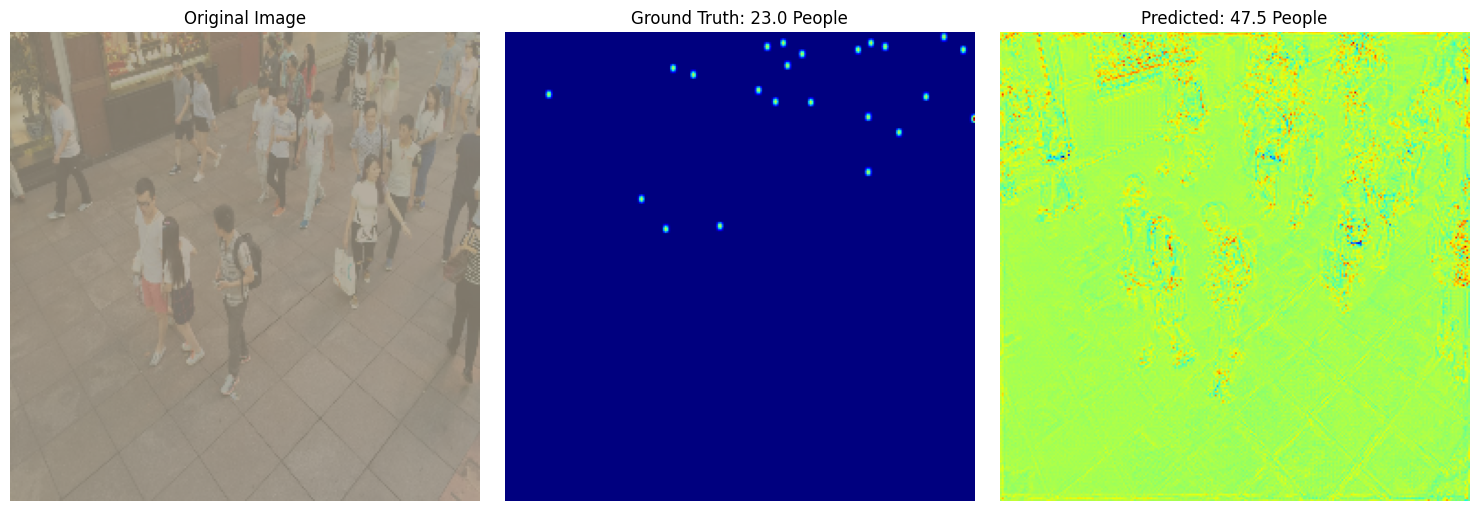

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


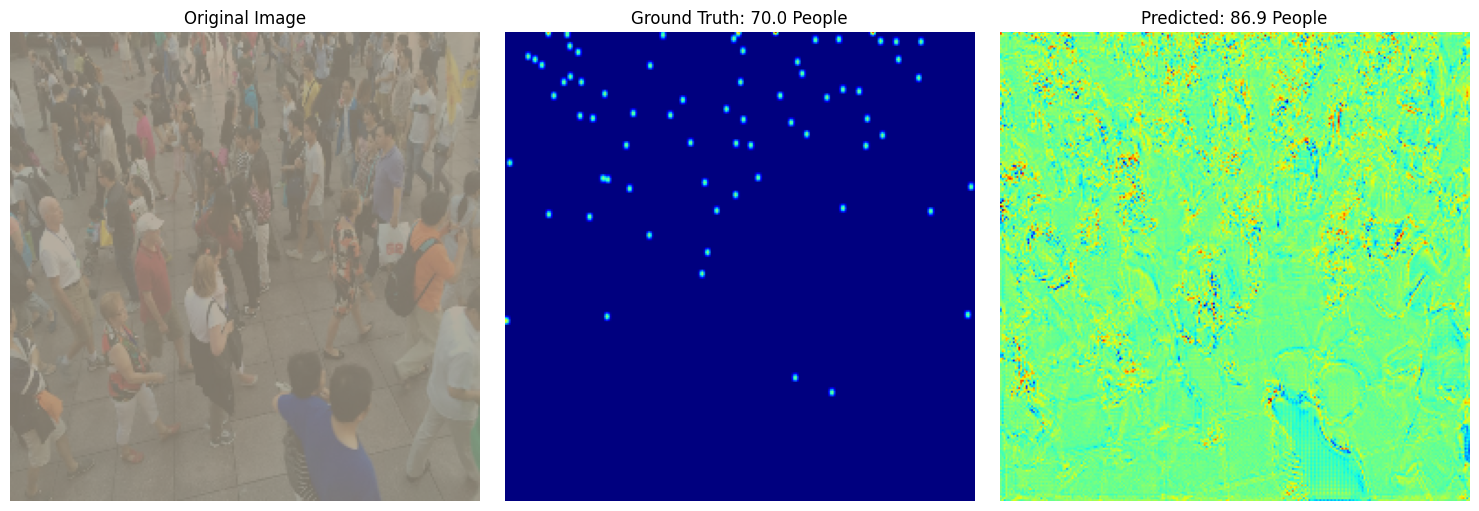

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


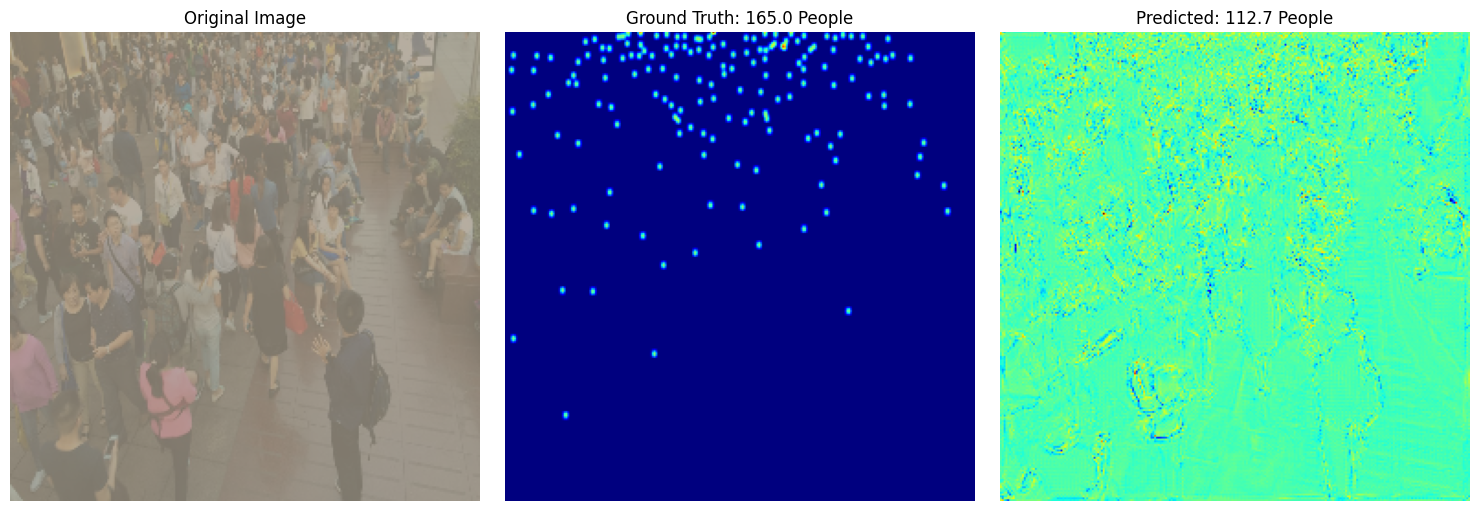

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


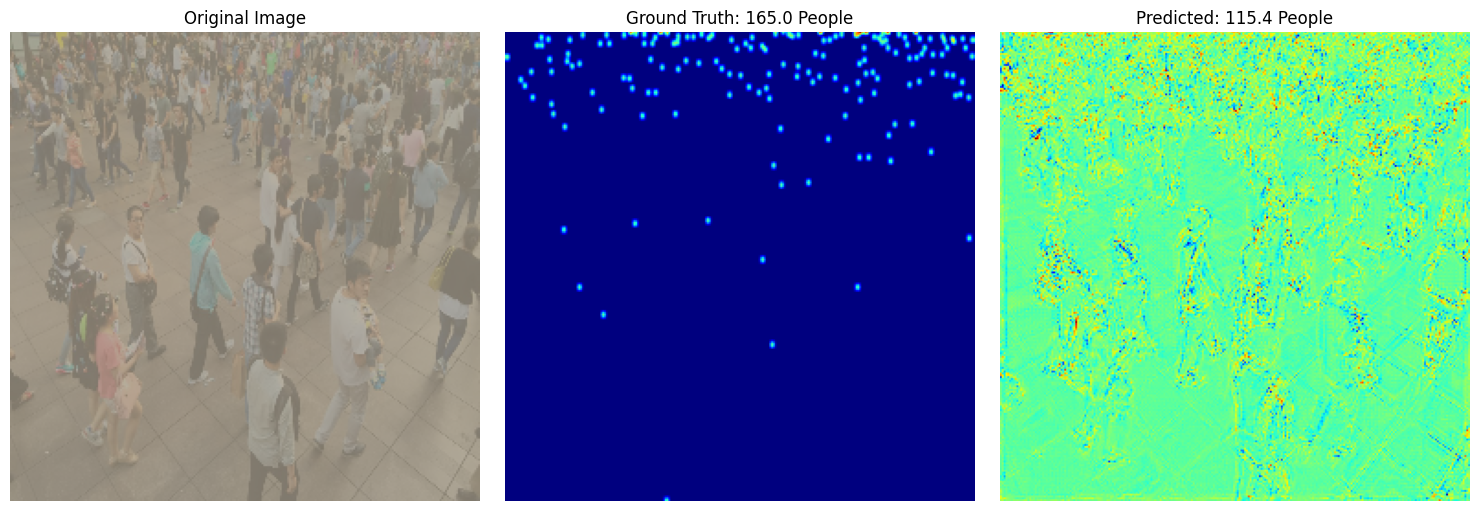

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


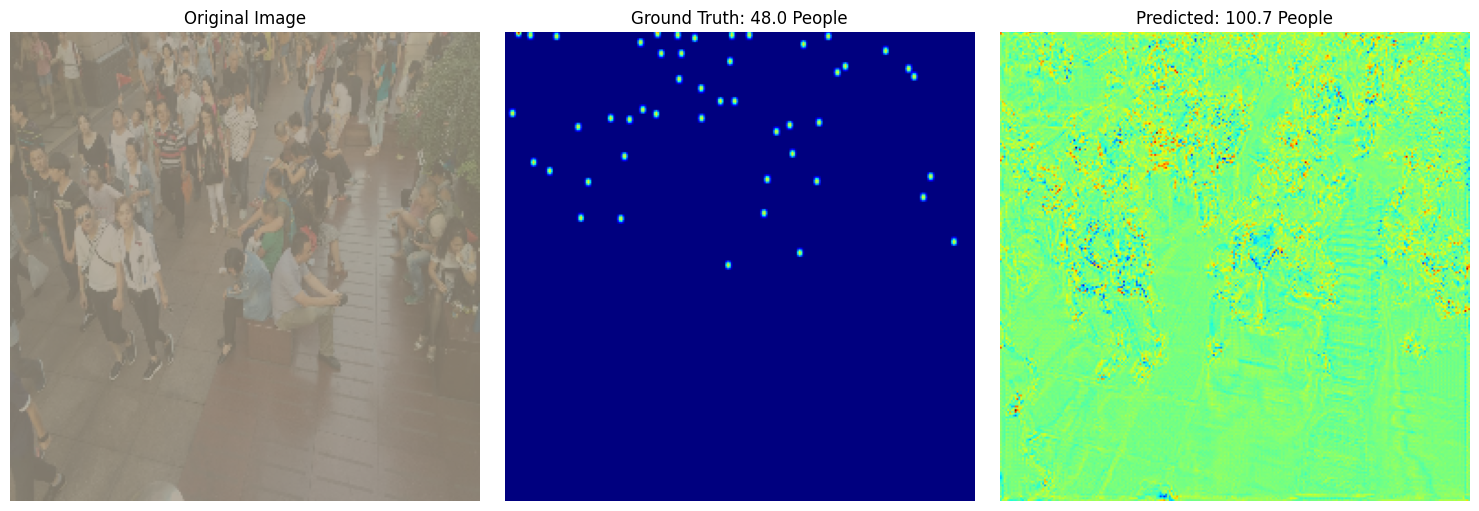

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 

In [ ]:
model.load_weights("best_model.h5")

mae = 0.0
num_samples = 0

for batch in test_ds:
    image, gt_map = batch
    pred_map = model.predict(image)[0, :, :, 0]  
    gt_map = gt_map[0, :, :, 0].numpy()

    pred_count = np.sum(pred_map)
    gt_count = np.sum(gt_map)
    mae += abs(pred_count - gt_count)
    num_samples += 1

    if num_samples <= 5:  
        img_np = image[0].numpy()
        img_np = (img_np * [0.229, 0.224, 0.225]) + [0.485, 0.456, 0.406]  # unnormalize
        img_np = np.clip(img_np, 0, 1)

        plt.figure(figsize=(15, 5))

        plt.subplot(1, 3, 1)
        plt.imshow(img_np)
        plt.title("Original Image")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.imshow(gt_map, cmap='jet')
        plt.title(f"Ground Truth: {gt_count:.1f} People")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.imshow(pred_map, cmap='jet')
        plt.title(f"Predicted: {pred_count:.1f} People")
        plt.axis("off")

        plt.tight_layout()
        plt.show()

print(f"Test MAE (Mean Absolute Error): {mae / num_samples:.2f}")
